In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import xarray as xr
from dask.distributed import Client

from srm import catalog
from srm.utils import open_icechunk, resolve_s3_glob

In [2]:
client = Client()
client

/opt/coiled/env/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42125 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://cluster-vpzqb.dask.host/jupyter/proxy/42125/status,
Dashboard: https://cluster-vpzqb.dask.host/jupyter/proxy/42125/status,Workers: 8
Total threads: 64,Total memory: 244.48 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37875,Workers: 0
Dashboard: https://cluster-vpzqb.dask.host/jupyter/proxy/42125/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34121,Total threads: 8
Dashboard: https://cluster-vpzqb.dask.host/jupyter/proxy/40085/status,Memory: 30.56 GiB
Nanny: tcp://127.0.0.1:44087,


In [3]:
def get_fname(root_path, var, scenario, version="test015_benchmark", ens="003", scenario2=None):
    if scenario2 is None:
        scenario2 = scenario
    fname = (
        root_path
        + version
        + "/"
        + scenario
        + "/CESM2-WACCM/"
        + var
        + "/"
        + ens
        + "/global/era5/*/"
        + scenario2
        + ".icechunk/"
    )
    return fname

In [4]:
era5 = catalog.get("ERA5").to_xarray()

In [27]:
root_path = "s3://carbonplan-srm/output/production/"
version = "v2026.06.22"
scenario="historical"
var="rsds"
ens="r3i1p1f1"
lat = 23
lon = -8
fname = get_fname(root_path=root_path, var=var, scenario=scenario, version=version, ens=ens)
fname = resolve_s3_glob(fname)
downscaled_da = open_icechunk(path=fname)[var]

### Inspect a single location in the Sahara

Comparing downscaled rsds with era5 rsds we see instances of 0 shortwave. We don't want that! The lowest in ERA5 is usually higher.

In [22]:
coarse = catalog.get("CESM2-WACCM-historical-icechunk").to_xarray()["tas"].sel(ensemble_member="001")

In [ ]:
# Downscaling can do weird things when it's having to work very hard. Case in point this GCM compared to ERA5

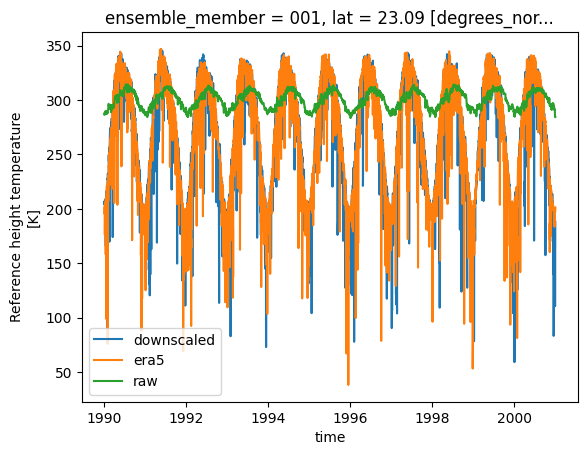

In [33]:
downscaled_da.sel(lat=lat, lon=lon, method='nearest').sel(time=slice('1990', '2000')).plot(label='downscaled')
era5.sel(lat=lat, lon=lon, method='nearest').sel(time=slice('1990', '2000')).rsds.plot(label='era5')
coarse.sel(lat=lat, lon=lon, method='nearest').sel(time=slice('1990', '2000')).plot(label='raw')
plt.legend()

In [38]:
scenario="ssp245"
var="rsds"
ens="003"
fname = get_fname(root_path=root_path, var=var, scenario=scenario, version=version, ens=ens)
fname = resolve_s3_glob(fname)
downscaled_da = open_icechunk(path=fname)[var]
coarse = catalog.get("CESM2-WACCM-SSP245-icechunk").to_xarray()["tas"].sel(ensemble_member="001")

The downscaling introduces days with ~zero shortwave even though the raw doesn't approach it. The distribution is stretched so far!

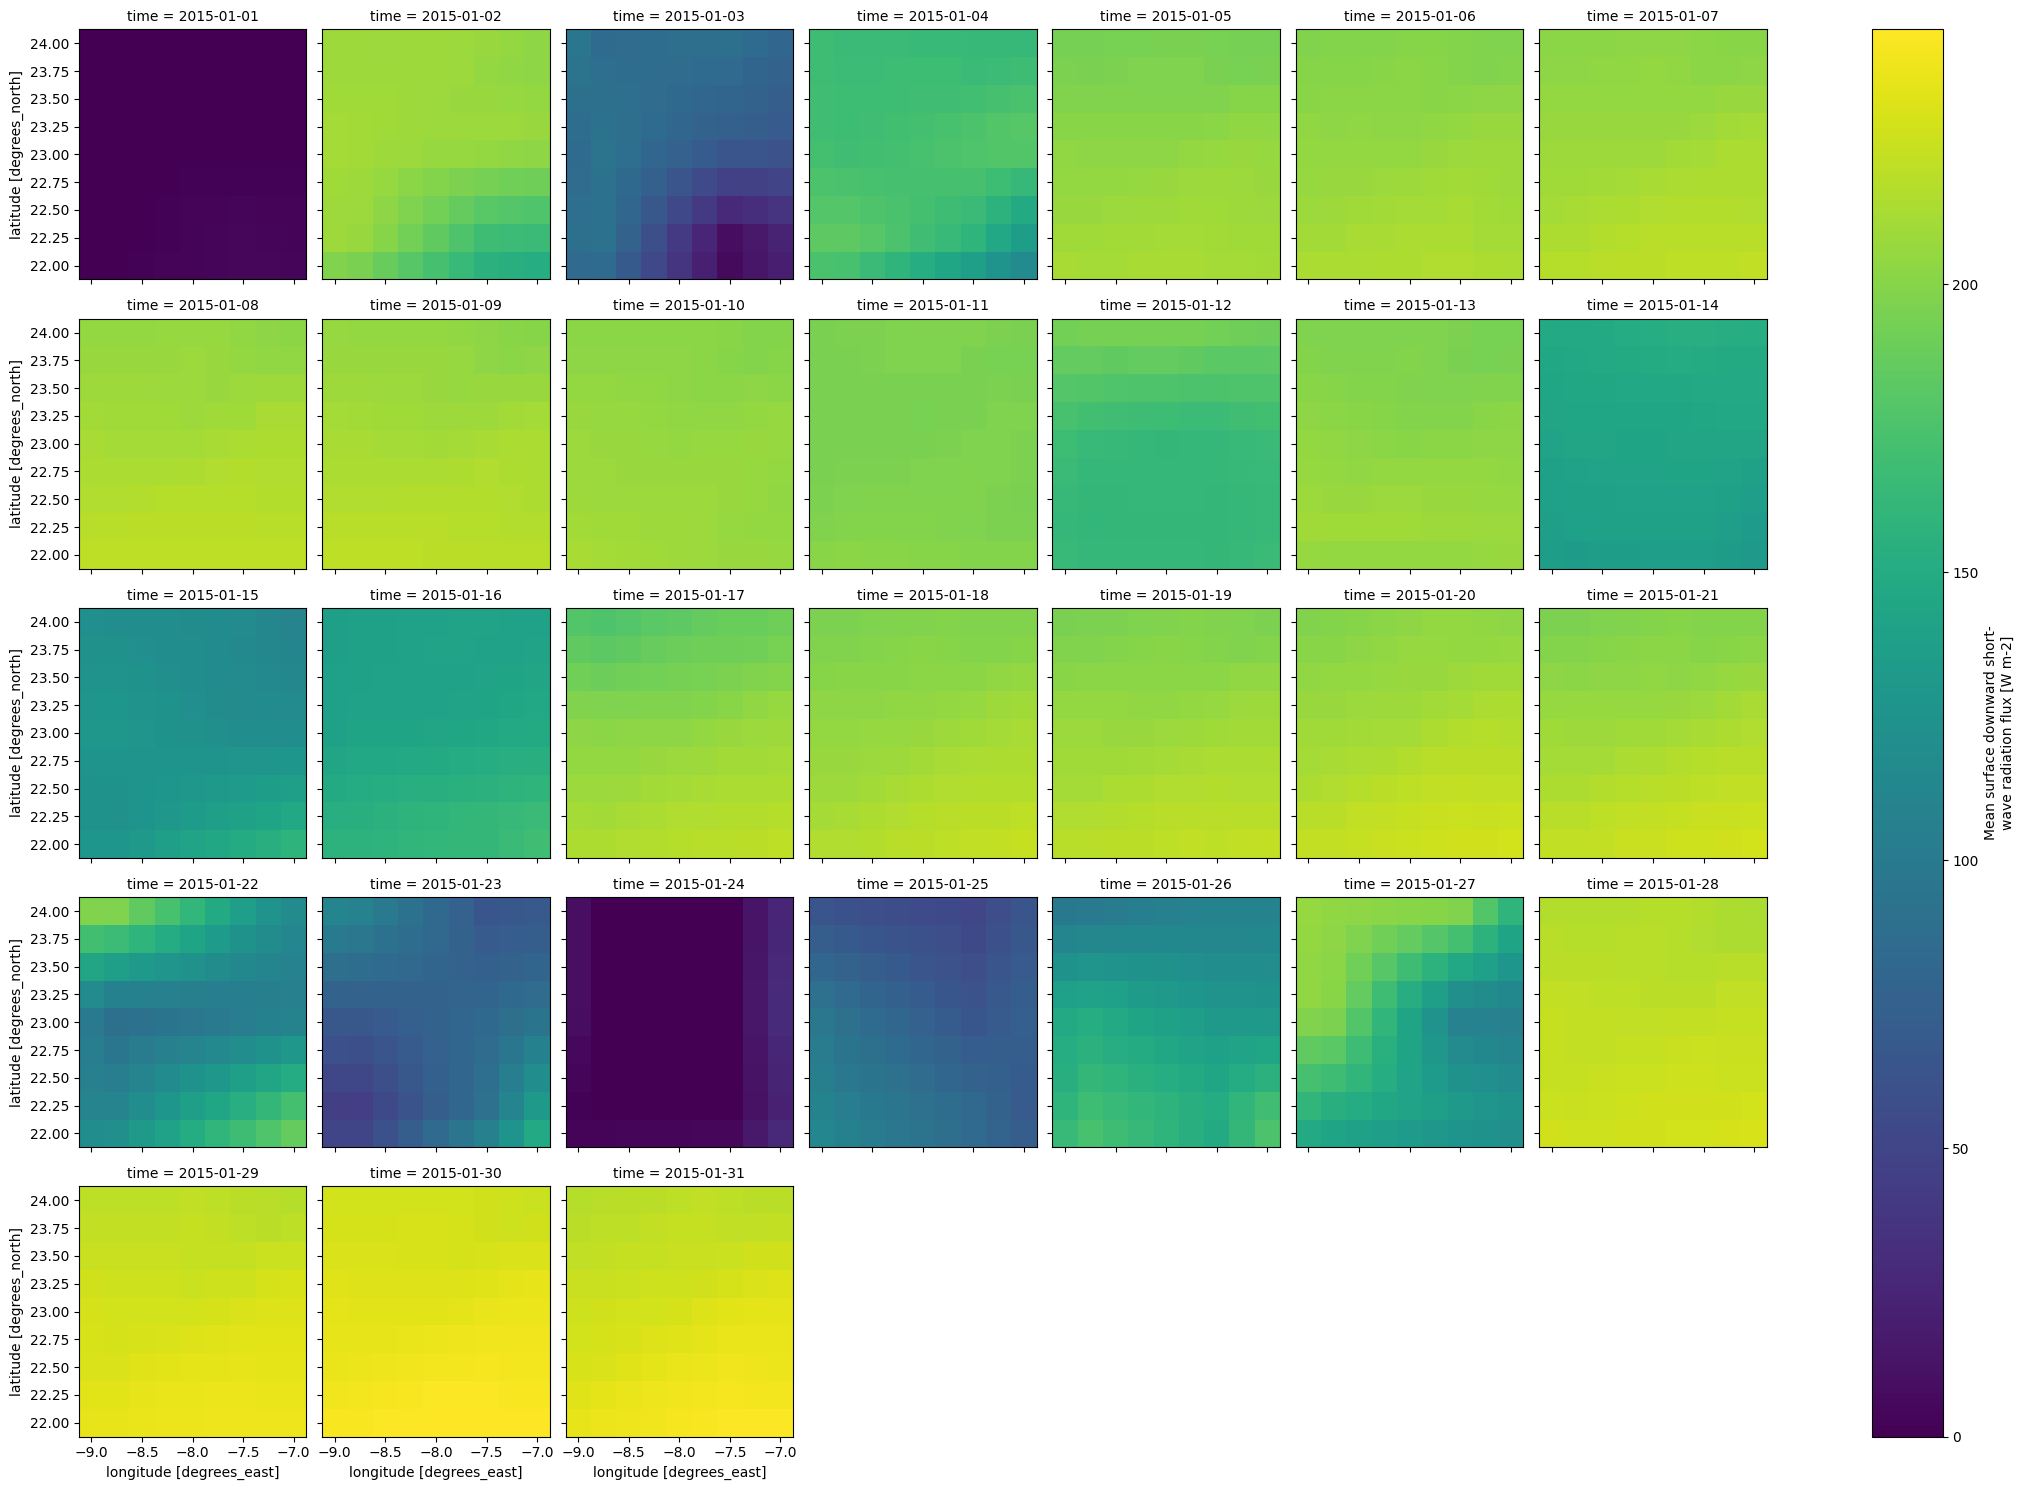

In [39]:
downscaled_da.sel(lat=slice(lat-1, lat+1), 
                  lon=slice(lon-1, lon+1), 
                  time=slice('2015-01-01', '2015-01-31')).plot(col='time', col_wrap=7)

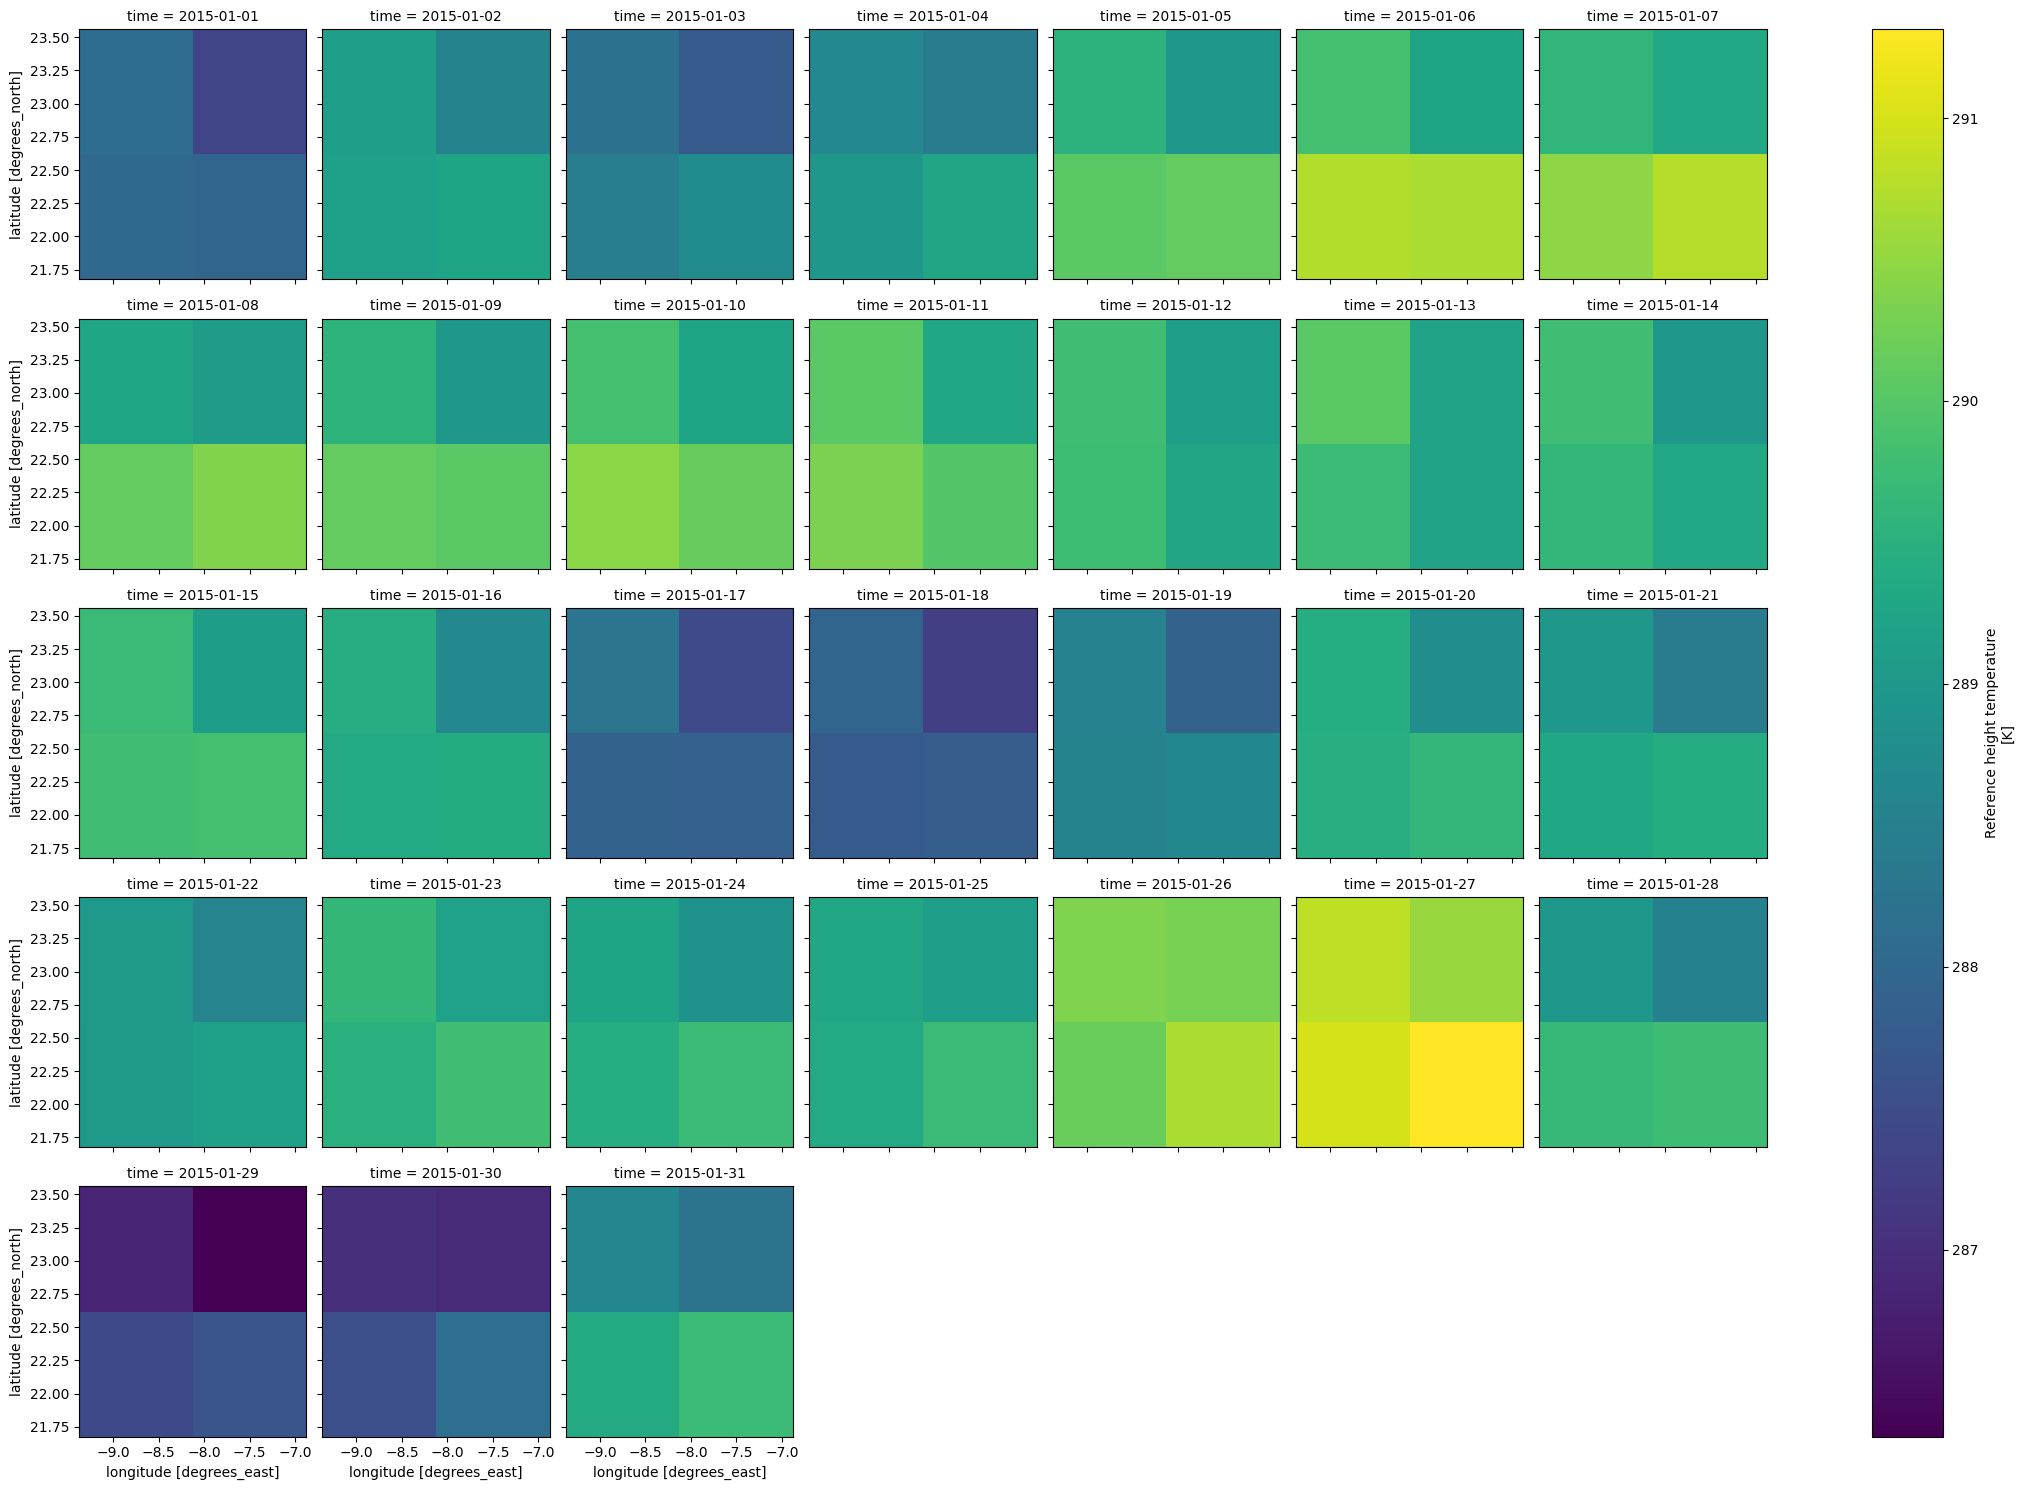

In [40]:
coarse.sel(lat=slice(lat-1, lat+1), 
                  lon=slice(lon-1, lon+1), 
                  time=slice('2015-01-01', '2015-01-31')).plot(col='time', col_wrap=7)

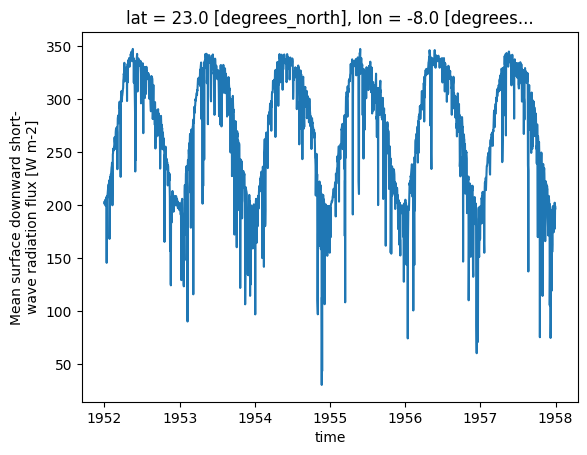

In [9]:
era5.sel(lat=lat, lon=lon, method='nearest').sel(time=slice('1952', '1957')).rsds.plot()

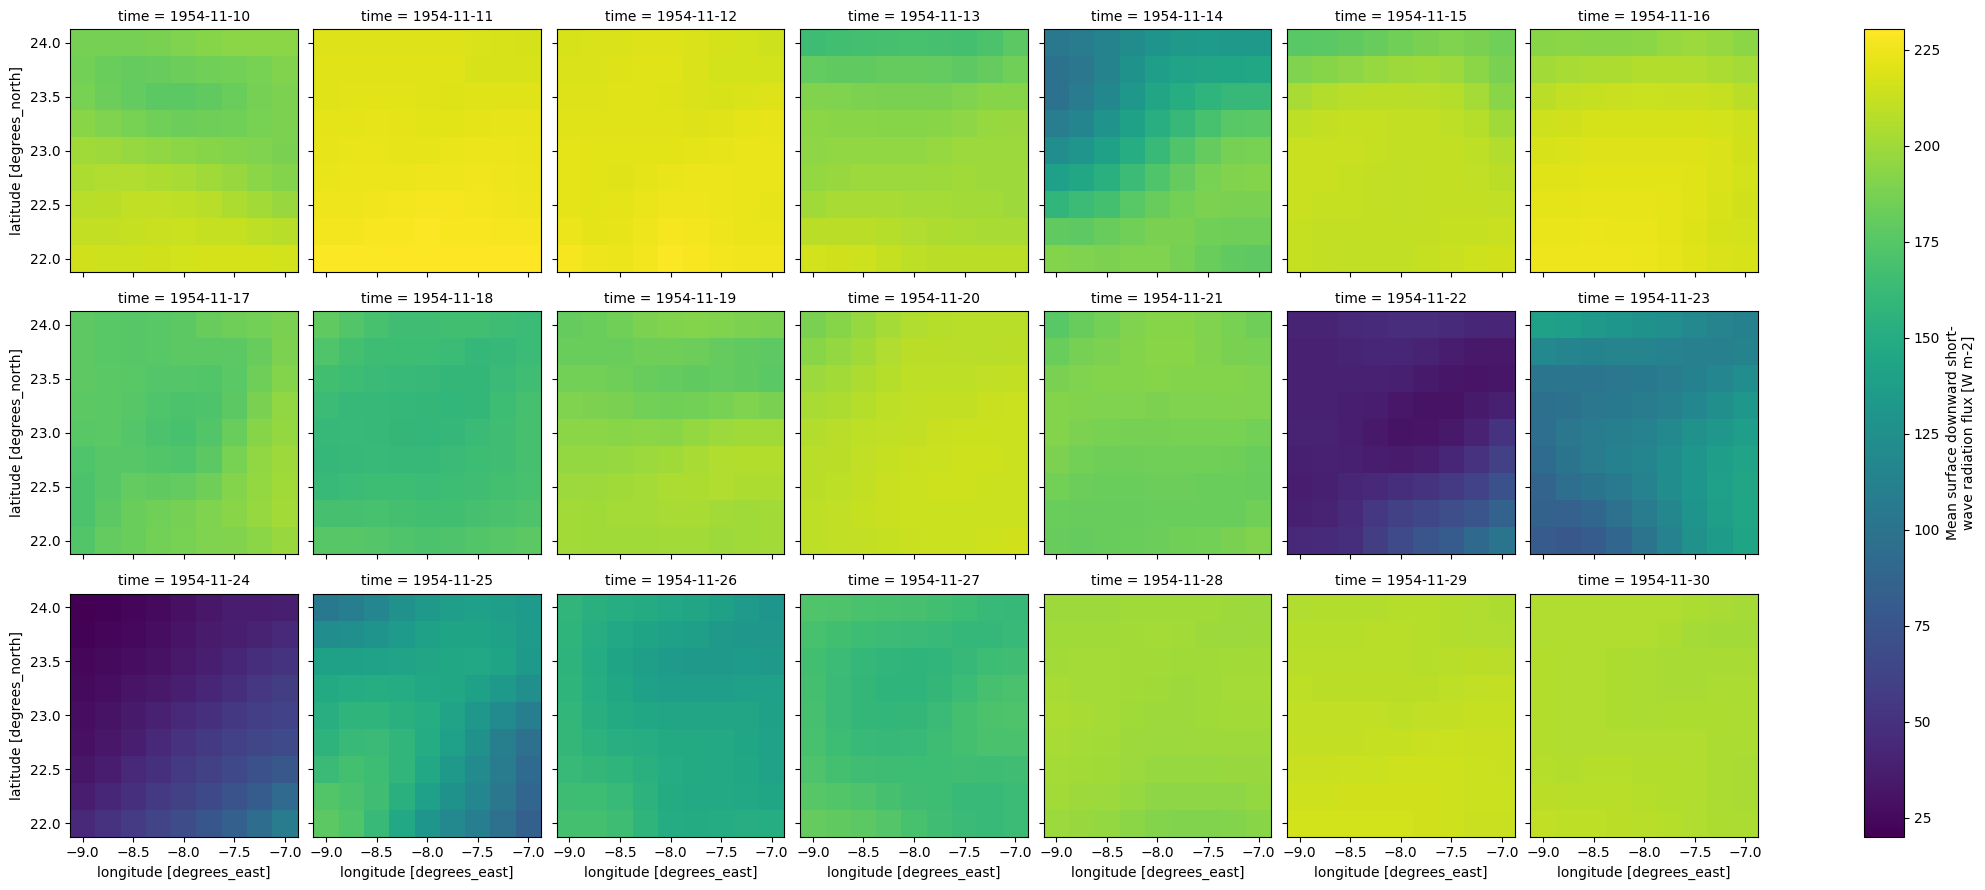

In [15]:
era5.sel(lat=slice(lat-1, lat+1), 
                  lon=slice(lon-1, lon+1),
         time=slice('1954-11-10', '1954-11-30')).rsds.plot(col='time', col_wrap=7)